# Steel Surface Defect Classification Using CNN Transfer Learning
Custom CNN vs. MobileNetV2 vs. ResNet50 + Grad-CAM + SHAP

Dataset: NEU-DET (Northeastern University Surface Defect Database), 6 classes, 1800 grayscale images.

This notebook:

1.Loads and inspects the NEU-DET dataset (auto-detects the Kaggle input path)

2.Builds a stratified 70/15/15 train/validation/test split

3.Applies preprocessing and data augmentation

4.Trains a custom CNN baseline

5.Trains MobileNetV2 and ResNet50 via transfer learning (frozen + fine-tuned stages)

6.Evaluates and compares all three models (accuracy, precision, recall, F1, confusion matrix)

7.Generates Grad-CAM and SHAP explanations

8.Reports efficiency metrics (parameter count, model size, inference time)

9.Saves every figure/table

# 1. Setup and Imports

import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = os.environ.get("STEEL_DEFECT_DATA", "data/NEU-DET")
RESULTS_DIR = "results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TABLE_DIR = os.path.join(RESULTS_DIR, "tables")
MODEL_DIR = "models"

for directory in [RESULTS_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(directory, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Dataset root:", DATA_ROOT)


In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("Number of GPUs available:", len(gpus))
for gpu in gpus:
    print(gpu)

Number of GPUs available: 1
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import os
import pandas as pd

CLASS_NAMES = [
    "crazing", "inclusion", "patches",
    "pitted_surface", "rolled-in_scale", "scratches"
]

def collect_images_from_root(root):
    """Recursively collect image paths and infer labels from class folders."""
    rows = []
    for dirpath, _, filenames in os.walk(root):
        for file in filenames:
            if not file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            filepath = os.path.join(dirpath, file)
            parts = set(os.path.normpath(filepath).split(os.sep))
            label = next((cls for cls in CLASS_NAMES if cls in parts), None)
            if label is None:
                continue
            rows.append({"filepath": filepath, "label": label})
    return pd.DataFrame(rows)


# 2. Locate Dataset and Build Master DataFrame

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_ROOT}. "
        "Set STEEL_DEFECT_DATA to the extracted NEU-DET directory."
    )

df_all = collect_images_from_root(DATA_ROOT)
if df_all.empty:
    raise ValueError("No supported image files were found under DATA_ROOT.")

print(f"Total images found: {len(df_all)}")
print(df_all['label'].value_counts().reindex(CLASS_NAMES))


#3. Dataset Visualization

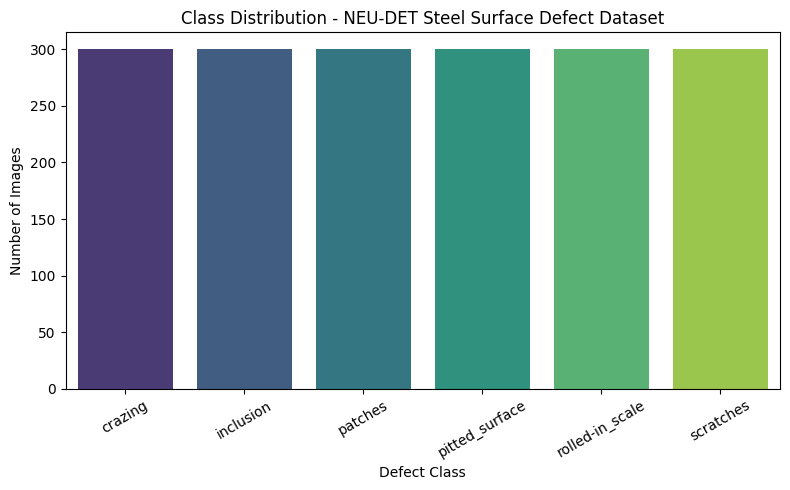

In [ ]:
# Class distribution plot
plt.figure(figsize=(8,5))
sns.countplot(data=df_all, x="label", order=CLASS_NAMES, palette="viridis")
plt.title("Class Distribution - NEU-DET Steel Surface Defect Dataset")
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.pdf"), dpi=300)
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=300)
plt.show()


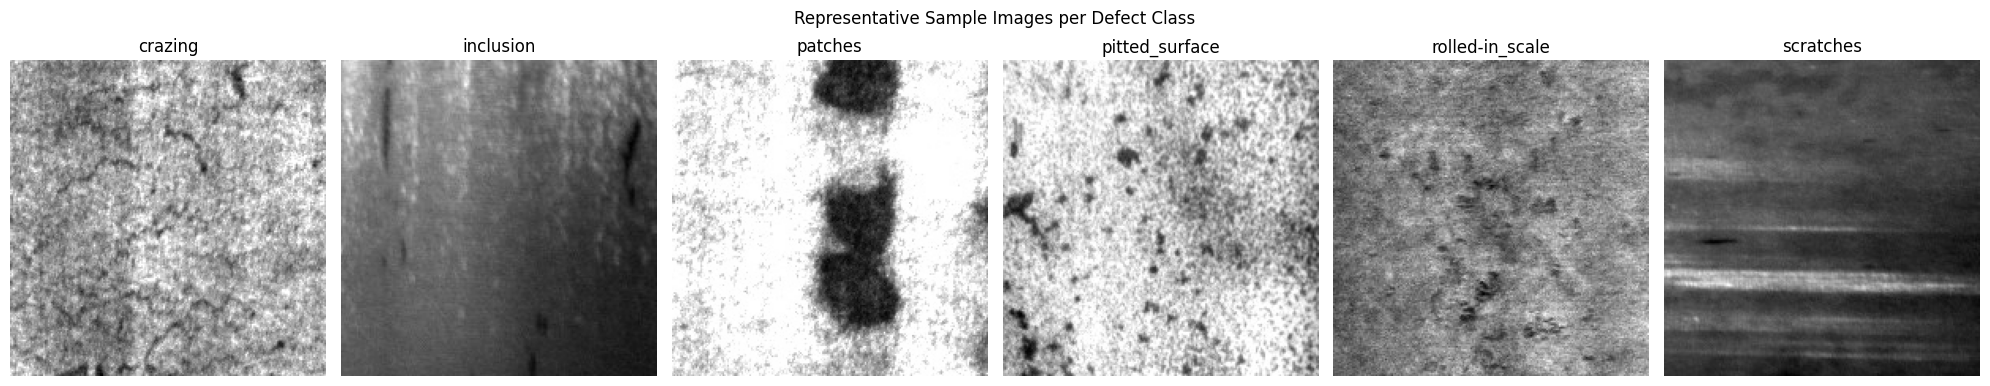

In [ ]:
# Representative images from every class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20,4))
for ax, cls in zip(axes, CLASS_NAMES):
    sample_path = df_all[df_all["label"] == cls]["filepath"].iloc[0]
    img = tf.keras.utils.load_img(sample_path, color_mode="grayscale")
    ax.imshow(img, cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Representative Sample Images per Defect Class")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_samples.pdf"), dpi=300)
plt.savefig(os.path.join(FIG_DIR, "class_samples.png"), dpi=300)
plt.show()


# 4. Stratified Train / Validation / Test Split (70/15/15)
The dataset ships with only a train/validation split and no dedicated test set. We recombine everything and create a proper three-way stratified split to avoid data leakage and enable honest generalization testing.




In [ ]:
df_train, df_temp = train_test_split(
    df_all, test_size=0.30, stratify=df_all["label"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp["label"], random_state=SEED
)

print("Train:", len(df_train), "| Validation:", len(df_val), "| Test:", len(df_test))
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Count": [len(df_train), len(df_val), len(df_test)],
    "Percentage": [f"{len(df_train)/len(df_all)*100:.1f}%",
                    f"{len(df_val)/len(df_all)*100:.1f}%",
                    f"{len(df_test)/len(df_all)*100:.1f}%"]
})
split_summary.to_csv(os.path.join(TABLE_DIR, "data_split_summary.csv"), index=False)
split_summary


Train: 1260 | Validation: 270 | Test: 270


,Split,Count,Percentage
0,Train,1260,70.0%
1,Validation,270,15.0%
2,Test,270,15.0%


# 5. Data Generators (Preprocessing + Augmentation)
Images are resized to 224x224 and converted to 3-channel RGB (required by ImageNet-pretrained backbones). Augmentation (rotation, shift, zoom, flips, brightness) is applied ONLY to the training generator to avoid inflating validation/test performance.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    vertical_flip=True,   # valid here: defect orientation on a rolled steel strip is not semantically meaningful
    fill_mode="nearest"
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, df, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, df_train, shuffle=True)
val_gen   = make_generator(val_test_datagen, df_val, shuffle=False)
test_gen  = make_generator(val_test_datagen, df_test, shuffle=False)


Found 1260 validated image filenames belonging to 6 classes.
Found 270 validated image filenames belonging to 6 classes.
Found 270 validated image filenames belonging to 6 classes.


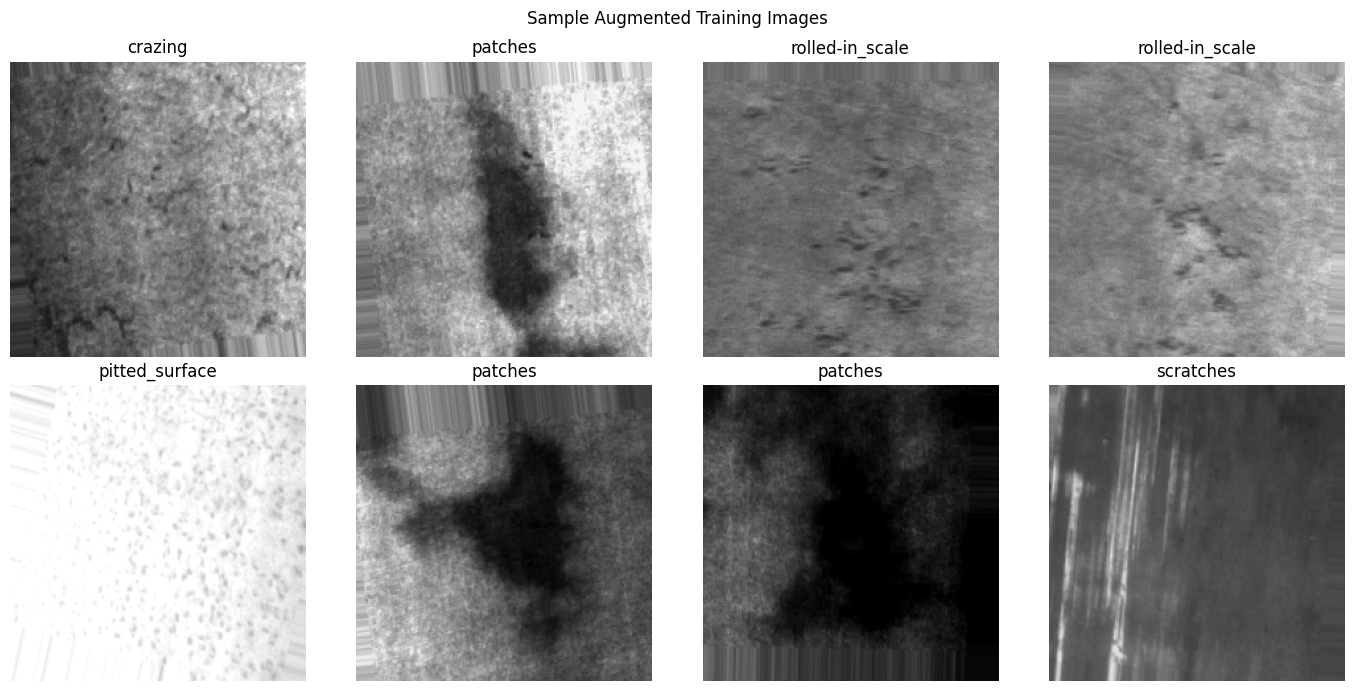

In [ ]:
# Visualize a batch of augmented training images
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(14,7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(CLASS_NAMES[np.argmax(labels[i])])
    ax.axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "augmentation_examples.pdf"), dpi=300)
plt.savefig(os.path.join(FIG_DIR, "augmentation_examples.png"), dpi=300)
plt.show()

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def make_datagens(preprocess_fn):
    train_dg = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.1, brightness_range=[0.85, 1.15],
        horizontal_flip=True, vertical_flip=True, fill_mode="nearest"
    )
    val_test_dg = ImageDataGenerator(preprocessing_function=preprocess_fn)
    return train_dg, val_test_dg

def make_gen(datagen, df, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=df, x_col="filepath", y_col="label",
        target_size=IMG_SIZE, color_mode="rgb", class_mode="categorical",
        classes=CLASS_NAMES, batch_size=BATCH_SIZE, shuffle=shuffle, seed=SEED
    )

# Custom CNN: simple 0-1 scaling (trained from scratch, no ImageNet assumptions)
plain_preprocess = lambda x: x / 255.0
train_dg_cnn, valtest_dg_cnn = make_datagens(plain_preprocess)
train_gen_cnn = make_gen(train_dg_cnn, df_train, True)
val_gen_cnn   = make_gen(valtest_dg_cnn, df_val, False)
test_gen_cnn  = make_gen(valtest_dg_cnn, df_test, False)

# ResNet50: its own required ImageNet preprocessing
train_dg_res, valtest_dg_res = make_datagens(resnet_preprocess)
train_gen_res = make_gen(train_dg_res, df_train, True)
val_gen_res   = make_gen(valtest_dg_res, df_val, False)
test_gen_res  = make_gen(valtest_dg_res, df_test, False)

print("New generators created: train_gen_cnn/val_gen_cnn/test_gen_cnn and train_gen_res/val_gen_res/test_gen_res")

Found 1260 validated image filenames belonging to 6 classes.
Found 270 validated image filenames belonging to 6 classes.
Found 270 validated image filenames belonging to 6 classes.
Found 1260 validated image filenames belonging to 6 classes.
Found 270 validated image filenames belonging to 6 classes.
Found 270 validated image filenames belonging to 6 classes.
New generators created: train_gen_cnn/val_gen_cnn/test_gen_cnn and train_gen_res/val_gen_res/test_gen_res


# 6. Custom CNN Baseline

In [ ]:
def build_custom_cnn(input_shape=(224,224,3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu", name="last_conv")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="custom_cnn")
    return model

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

# 7. Common Training Utilities (Callbacks)

In [ ]:
def get_callbacks(model_name, patience=8):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, f"{model_name}_best.keras"),
                                   monitor="val_loss", save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
    ]

EPOCHS = 40

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
    axes[0].plot(history.history["accuracy"], label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{model_name}: Accuracy Curve")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{model_name}: Loss Curve")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_training_curves.pdf"), dpi=300)
    plt.savefig(os.path.join(FIG_DIR, f"{model_name}_training_curves.png"), dpi=300)
    plt.show()


# 8. Train Custom CNN

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 690ms/step - accuracy: 0.6786 - loss: 0.9192 - val_accuracy: 0.2407 - val_loss: 2.3835 - learning_rate: 1.0000e-04
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - accuracy: 0.8119 - loss: 0.5336 - val_accuracy: 0.8963 - val_loss: 0.3524 - learning_rate: 1.0000e-04
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 453ms/step - accuracy: 0.8373 - loss: 0.4664 - val_accuracy: 0.8370 - val_loss: 0.4117 - learning_rate: 1.0000e-04
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 506ms/step - accuracy: 0.8548 - loss: 0.4033 - val_accuracy: 0.9037 - val_loss: 0.3242 - learning_rate: 1.0000e-04
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 461ms/step - accuracy: 0.8857 - loss: 0.3211 - val_accuracy: 0.9519 - val_loss: 0.1876 - learning_rate: 1.0000e-04
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 499ms/step - accuracy: 0.8952 - loss: 0.2851 - val_accuracy: 0.9037 - val_loss: 0.2447 - learning_rate: 1.0000e-04
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 478ms/step - acc

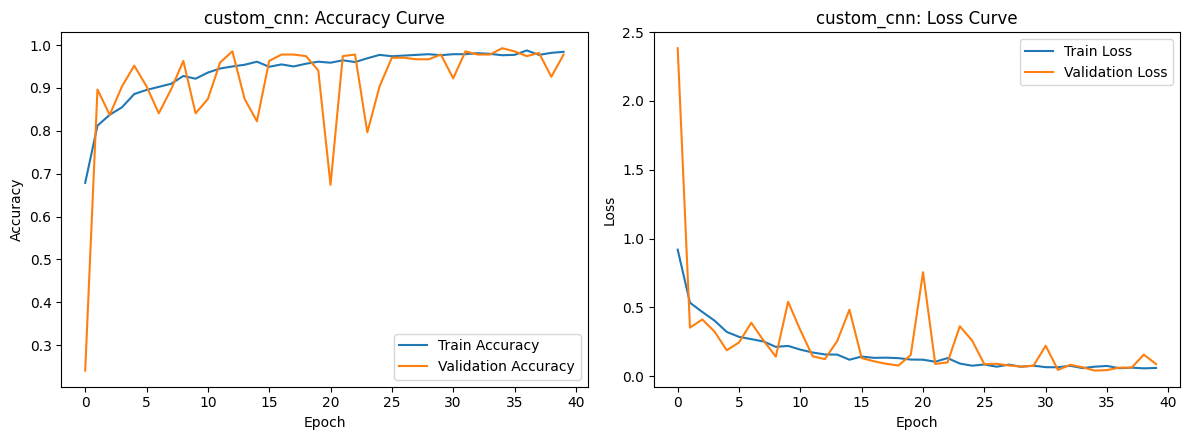

Custom CNN training time: 785.7s


In [ ]:
t0 = time.time()
history_cnn = custom_cnn.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=EPOCHS,
    callbacks=get_callbacks("custom_cnn", patience=12),
    verbose=1
)
train_time_cnn = time.time() - t0
plot_training_curves(history_cnn, "custom_cnn")
print(f"Custom CNN training time: {train_time_cnn:.1f}s")

## 9. MobileNetV2 Transfer Learning
Stage 1: frozen backbone, train only the new classification head.
Stage 2: fine-tune the last block of the backbone with a low learning rate.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8325 - loss: 0.4618 - val_accuracy: 0.9741 - val_loss: 0.0996 - learning_rate: 0.0010
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 444ms/step - accuracy: 0.9762 - loss: 0.0895 - val_accuracy: 0.9741 - val_loss: 0.0859 - learning_rate: 0.0010
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 454ms/step - accuracy: 0.9857 - loss: 0.0525 - val_accuracy: 0.9852 - val_loss: 0.0478 - learning_rate: 0.0010
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 460ms/step - accuracy: 0.9857 - loss: 0.0409 - val_accuracy: 0.9926 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 444ms/step - accuracy: 0.9897 - loss: 0.0371 - val_accuracy: 0.9926 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 471ms/step - accuracy: 0.9817 - loss: 0.0579 - val_accuracy: 0.9741 - val_loss: 0.0980 - learning_rate: 0.0010
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━

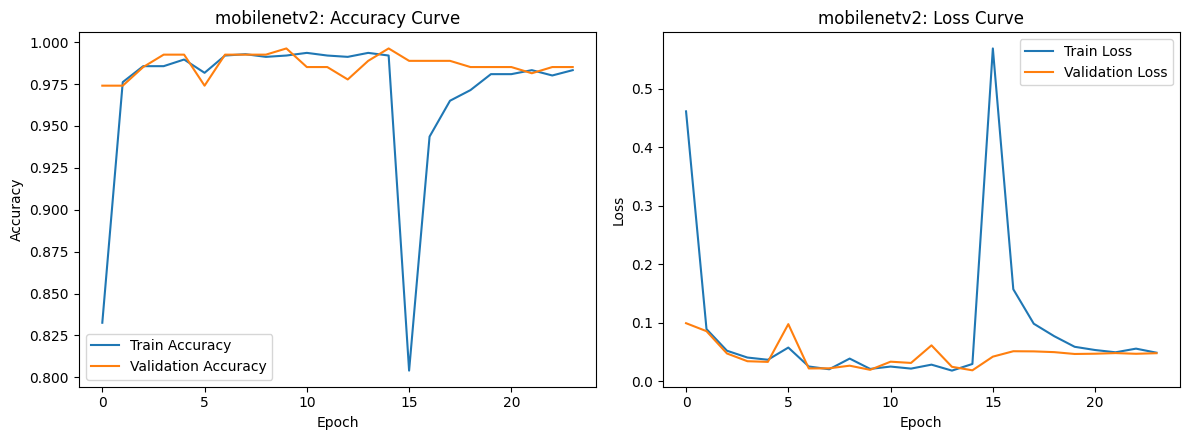

MobileNetV2 total training time: 515.2s


In [ ]:
def build_transfer_model(base_model_fn, name):
    base = base_model_fn(input_shape=(224,224,3), include_top=False, weights="imagenet")
    base.trainable = False
    inputs = base.input
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inputs, outputs, name=name)
    return model, base

mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, "mobilenetv2")
mobilenet_model.compile(optimizer=optimizers.Adam(1e-3),
                         loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
history_mnet_stage1 = mobilenet_model.fit(
    train_gen, validation_data=val_gen, epochs=15,
    callbacks=get_callbacks("mobilenetv2_stage1"), verbose=1
)

# Stage 2: fine-tune last ~30 layers
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(optimizer=optimizers.Adam(1e-5),
                         loss="categorical_crossentropy", metrics=["accuracy"])
history_mnet_stage2 = mobilenet_model.fit(
    train_gen, validation_data=val_gen, epochs=25,
    callbacks=get_callbacks("mobilenetv2_stage2"), verbose=1
)
train_time_mnet = time.time() - t0

# merge histories for plotting
history_mnet = {
    "accuracy": history_mnet_stage1.history["accuracy"] + history_mnet_stage2.history["accuracy"],
    "val_accuracy": history_mnet_stage1.history["val_accuracy"] + history_mnet_stage2.history["val_accuracy"],
    "loss": history_mnet_stage1.history["loss"] + history_mnet_stage2.history["loss"],
    "val_loss": history_mnet_stage1.history["val_loss"] + history_mnet_stage2.history["val_loss"],
}
class H: pass
h_obj = H(); h_obj.history = history_mnet
plot_training_curves(h_obj, "mobilenetv2")
print(f"MobileNetV2 total training time: {train_time_mnet:.1f}s")
mobilenet_model.save(os.path.join(MODEL_DIR, "mobilenetv2_final.keras"))


# 10. ResNet50 Transfer Learning

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 871ms/step - accuracy: 0.8952 - loss: 0.3125 - val_accuracy: 1.0000 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 502ms/step - accuracy: 0.9897 - loss: 0.0443 - val_accuracy: 0.9963 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 532ms/step - accuracy: 0.9913 - loss: 0.0339 - val_accuracy: 1.0000 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - accuracy: 0.9897 - loss: 0.0255 - val_accuracy: 1.0000 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 533ms/step - accuracy: 0.9905 - loss: 0.0248 - val_accuracy: 1.0000 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 532ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 7/15
40/40 ━━━━━━━━━━━━━━

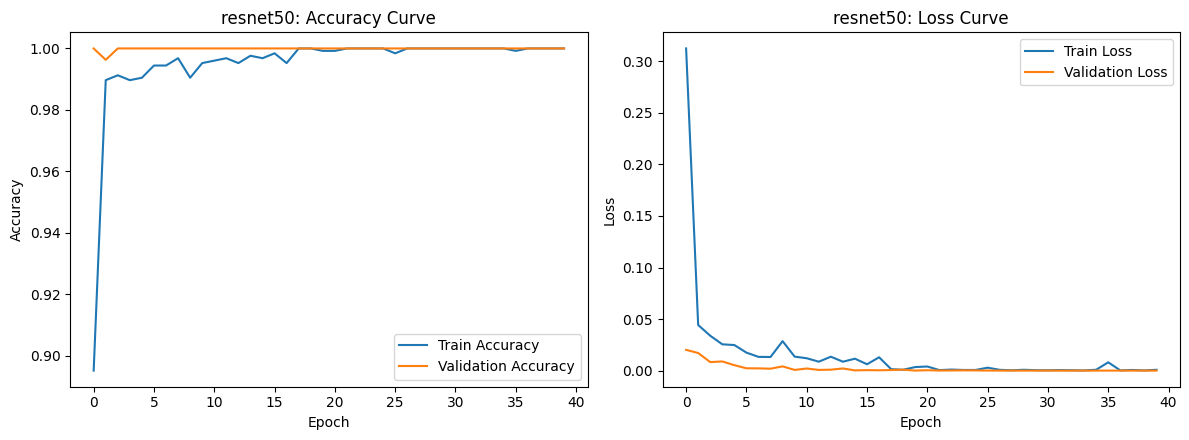

ResNet50 total training time: 930.5s


In [ ]:
resnet_model, resnet_base = build_transfer_model(ResNet50, "resnet50")
resnet_model.compile(optimizer=optimizers.Adam(1e-3),
                      loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
history_res_stage1 = resnet_model.fit(
    train_gen_res, validation_data=val_gen_res, epochs=15,
    callbacks=get_callbacks("resnet50_stage1"), verbose=1
)

# Fine-tune: unfreeze last 30 layers, but KEEP BatchNorm frozen (this was the bug)
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

resnet_model.compile(optimizer=optimizers.Adam(1e-5),
                      loss="categorical_crossentropy", metrics=["accuracy"])
history_res_stage2 = resnet_model.fit(
    train_gen_res, validation_data=val_gen_res, epochs=25,
    callbacks=get_callbacks("resnet50_stage2"), verbose=1
)
train_time_res = time.time() - t0

history_res = {
    "accuracy": history_res_stage1.history["accuracy"] + history_res_stage2.history["accuracy"],
    "val_accuracy": history_res_stage1.history["val_accuracy"] + history_res_stage2.history["val_accuracy"],
    "loss": history_res_stage1.history["loss"] + history_res_stage2.history["loss"],
    "val_loss": history_res_stage1.history["val_loss"] + history_res_stage2.history["val_loss"],
}
class H: pass
h_obj2 = H(); h_obj2.history = history_res
plot_training_curves(h_obj2, "resnet50")
print(f"ResNet50 total training time: {train_time_res:.1f}s")
resnet_model.save(os.path.join(MODEL_DIR, "resnet50_final.keras"))

# 11. Evaluation Framework

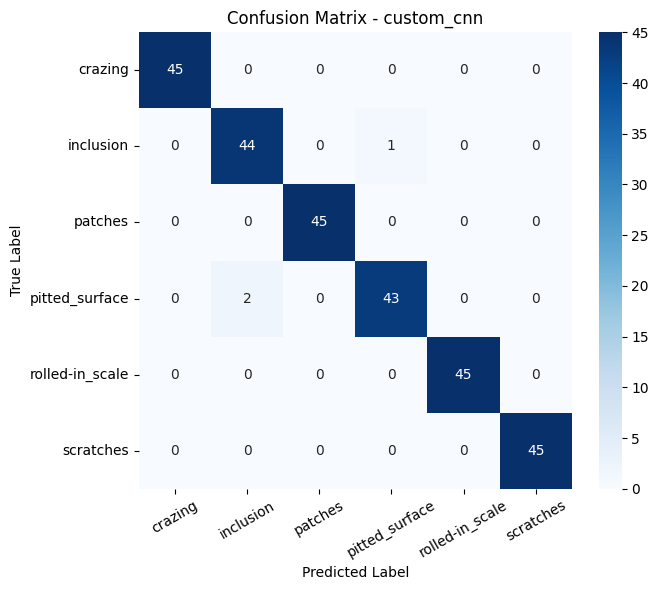

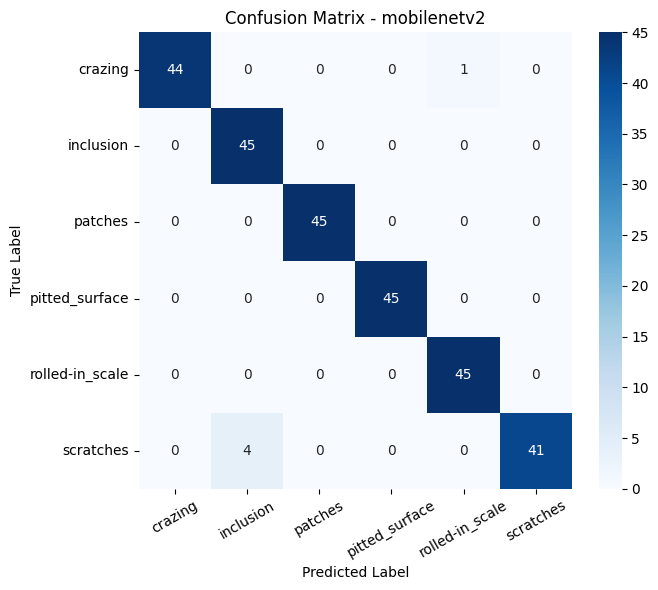

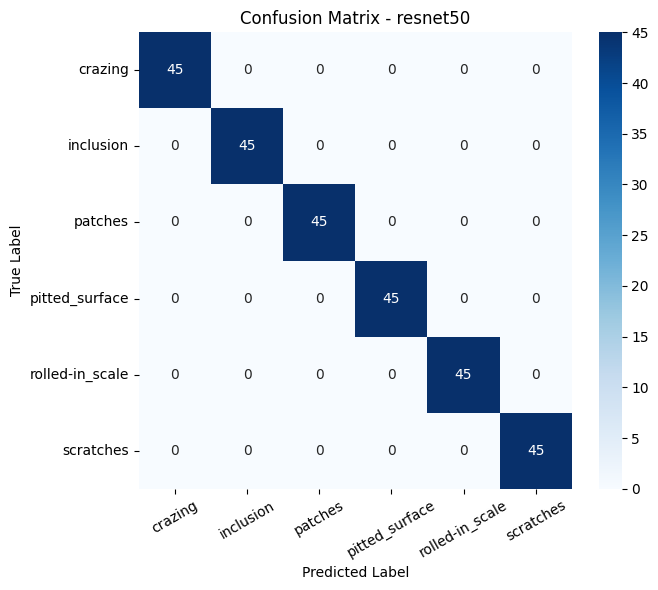

In [ ]:
def get_true_pred(model, generator):
    generator.reset()
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes
    return y_true, y_pred, y_prob

def evaluate_model(model, generator, model_name):
    y_true, y_pred, y_prob = get_true_pred(model, generator)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
    except Exception:
        auc = np.nan

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model": model_name, "accuracy": acc, "macro_precision": precision,
        "macro_recall": recall, "macro_f1": f1, "weighted_f1": f1_weighted,
        "auc_macro": auc, "report": report, "confusion_matrix": cm,
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob
    }

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.xticks(rotation=30); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"confusion_matrix_{model_name}.pdf"), dpi=300)
    plt.savefig(os.path.join(FIG_DIR, f"confusion_matrix_{model_name}.png"), dpi=300)
    plt.show()

results_cnn = evaluate_model(custom_cnn, test_gen_cnn, "custom_cnn")
results_mnet = evaluate_model(mobilenet_model, test_gen, "mobilenetv2")
results_res = evaluate_model(resnet_model, test_gen_res, "resnet50")

for r in [results_cnn, results_mnet, results_res]:
    plot_confusion_matrix(r["confusion_matrix"], r["model"])


# 12. Model Comparison Table

In [ ]:
def count_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_variables])) + \
           int(np.sum([np.prod(v.shape) for v in model.non_trainable_variables]))

def model_size_mb(path):
    return round(os.path.getsize(path) / (1024*1024), 2)

def measure_inference_time(model, generator, n_batches=5):
    generator.reset()
    times = []
    for i, (imgs, _) in enumerate(generator):
        if i >= n_batches: break
        t0 = time.time()
        model.predict(imgs, verbose=0)
        times.append((time.time() - t0) / len(imgs))
    return np.mean(times) * 1000  # ms per image

comparison_rows = []
model_objs = {"custom_cnn": custom_cnn, "mobilenetv2": mobilenet_model, "resnet50": resnet_model}
results_objs = {"custom_cnn": results_cnn, "mobilenetv2": results_mnet, "resnet50": results_res}
train_times = {"custom_cnn": train_time_cnn, "mobilenetv2": train_time_mnet, "resnet50": train_time_res}

test_gens_map = {"custom_cnn": test_gen_cnn, "mobilenetv2": test_gen, "resnet50": test_gen_res}

for name, model in model_objs.items():
    r = evaluate_model(model, test_gens_map[name], name)
    results_objs[name] = r
    model_path = os.path.join(MODEL_DIR, f"{name}_final.keras")
    if not os.path.exists(model_path):
        model.save(model_path)
    comparison_rows.append({
        "Model": name,
        "Accuracy": round(r["accuracy"], 4),
        "Macro Precision": round(r["macro_precision"], 4),
        "Macro Recall": round(r["macro_recall"], 4),
        "Macro F1": round(r["macro_f1"], 4),
        "Weighted F1": round(r["weighted_f1"], 4),
        "AUC (macro)": round(r["auc_macro"], 4) if not np.isnan(r["auc_macro"]) else "N/A",
        "Params (M)": round(count_params(model) / 1e6, 2),
        "Model Size (MB)": model_size_mb(model_path),
        "Train Time (s)": round(train_times[name], 1),
        "Inference Time (ms/img)": round(measure_inference_time(model, test_gens_map[name]), 2)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(TABLE_DIR, "model_comparison.csv"), index=False)
comparison_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,AUC (macro),Params (M),Model Size (MB),Train Time (s),Inference Time (ms/img)
0,custom_cnn,0.9889,0.9890,0.9889,0.9889,0.9889,0.9998,0.46,5.31,785.7,11.31
1,mobilenetv2,0.9815,0.9828,0.9815,0.9815,0.9815,1.0000,2.59,24.61,515.2,29.92
2,resnet50,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,24.11,206.72,930.5,28.95


# 13. Per-Class Performance

In [ ]:
def classwise_table(results, model_name):
    rows = []
    for cls in CLASS_NAMES:
        d = results["report"][cls]
        rows.append({"Model": model_name, "Class": cls,
                      "Precision": round(d["precision"],3),
                      "Recall": round(d["recall"],3),
                      "F1-score": round(d["f1-score"],3),
                      "Support": int(d["support"])})
    return pd.DataFrame(rows)

classwise_all = pd.concat([
    classwise_table(results_cnn, "custom_cnn"),
    classwise_table(results_mnet, "mobilenetv2"),
    classwise_table(results_res, "resnet50"),
], ignore_index=True)
classwise_all.to_csv(os.path.join(TABLE_DIR, "classwise_performance.csv"), index=False)
classwise_all


,Model,Class,Precision,Recall,F1-score,Support
0,custom_cnn,crazing,1.000,1.000,1.000,45
1,custom_cnn,inclusion,0.957,0.978,0.967,45
2,custom_cnn,patches,1.000,1.000,1.000,45
3,custom_cnn,pitted_surface,0.977,0.956,0.966,45
4,custom_cnn,rolled-in_scale,1.000,1.000,1.000,45
5,custom_cnn,scratches,1.000,1.000,1.000,45
6,mobilenetv2,crazing,1.000,0.978,0.989,45
7,mobilenetv2,inclusion,0.918,1.000,0.957,45
8,mobilenetv2,patches,1.000,1.000,1.000,45
9,mobilenetv2,pitted_surface,1.000,1.000,1.000,45


# 14. Identify Best Model

In [ ]:
best_model_name = comparison_df.sort_values("Macro F1", ascending=False).iloc[0]["Model"]
best_model = model_objs[best_model_name]
print("Best performing model (by macro F1):", best_model_name)


Best performing model (by macro F1): resnet50


# 15. Grad-CAM Explainability

Using layer for Grad-CAM: conv5_block3_out


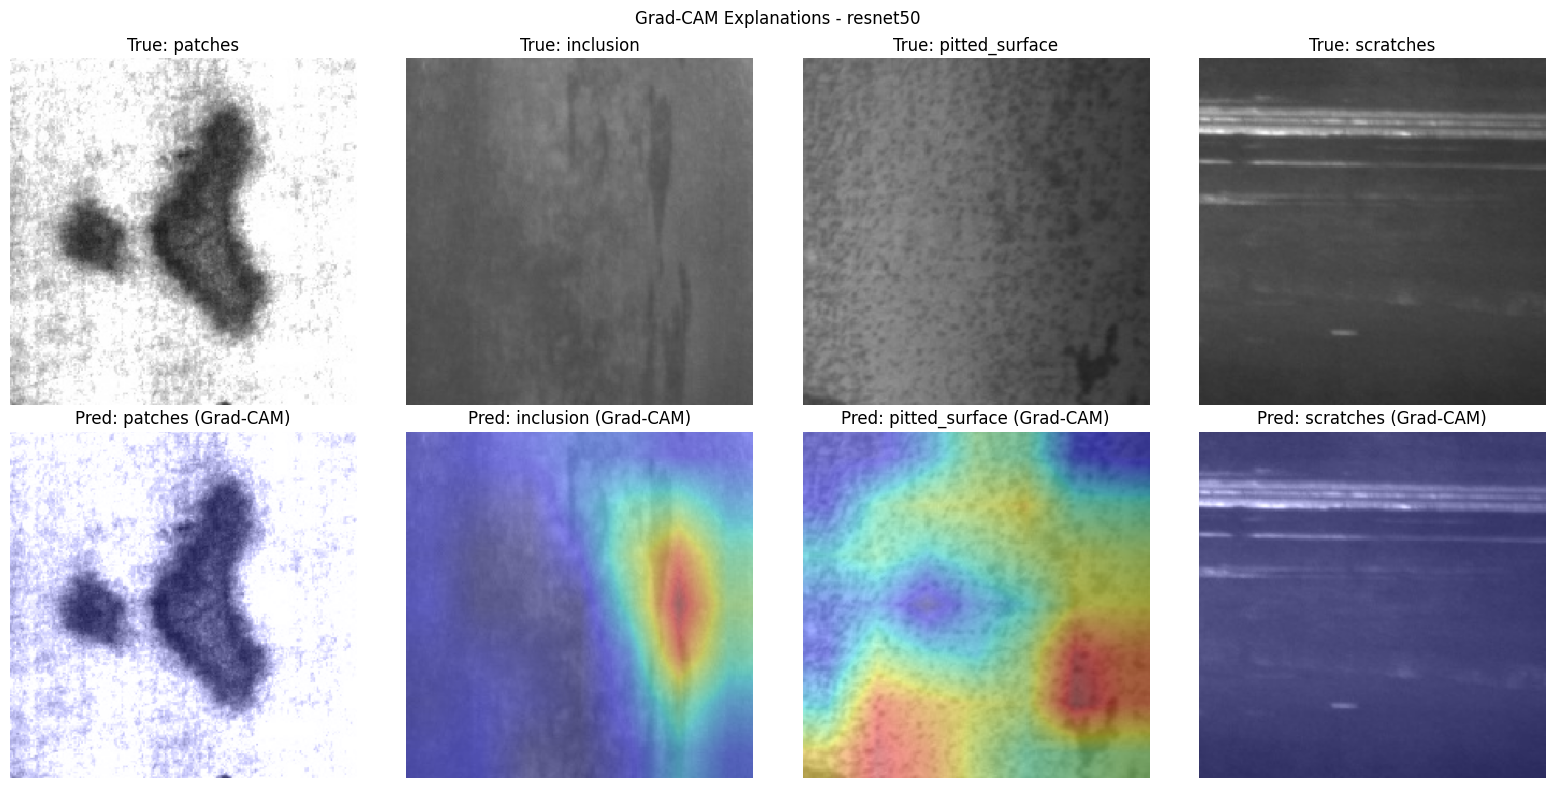

Grad-CAM predictions: ['patches -> patches', 'inclusion -> inclusion', 'pitted_surface -> pitted_surface', 'scratches -> scratches']


In [ ]:
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        try:
            shape = layer.output.shape
        except (AttributeError, ValueError):
            continue
        if shape is not None and len(shape) == 4:
            return layer.name
    raise ValueError("No 4D conv layer found")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_gradcam(img, heatmap, alpha=0.4):
    import matplotlib.cm as cm
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]
    superimposed = jet_heatmap * alpha + img
    superimposed = np.clip(superimposed, 0, 1)
    return superimposed

last_conv_name = get_last_conv_layer_name(best_model)
print("Using layer for Grad-CAM:", last_conv_name)

best_test_gen = test_gens_map[best_model_name]
best_test_gen.reset()
sample_imgs, sample_labels = next(best_test_gen)   # preprocessed, for the MODEL

test_gen.reset()
display_imgs, _ = next(test_gen)                    # plain 0-1, for DISPLAY only

fig, axes = plt.subplots(2, 4, figsize=(16,8))
for i in range(4):
    img_array = np.expand_dims(sample_imgs[i], axis=0)   # preprocessed -> model
    heatmap, pred_idx = make_gradcam_heatmap(img_array, best_model, last_conv_name)
    overlay = overlay_gradcam(display_imgs[i], heatmap)   # plain 0-1 -> visual overlay

    true_idx = np.argmax(sample_labels[i])
    axes[0, i].imshow(display_imgs[i]); axes[0, i].axis("off")
    axes[0, i].set_title(f"True: {CLASS_NAMES[true_idx]}")
    axes[1, i].imshow(overlay); axes[1, i].axis("off")
    axes[1, i].set_title(f"Pred: {CLASS_NAMES[pred_idx]} (Grad-CAM)")

plt.suptitle(f"Grad-CAM Explanations - {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "gradcam_examples.pdf"), dpi=300)
plt.savefig(os.path.join(FIG_DIR, "gradcam_examples.png"), dpi=300)
plt.show()

print("Grad-CAM predictions:", [CLASS_NAMES[np.argmax(sample_labels[i])] + " -> " + CLASS_NAMES[int(np.argmax(best_model.predict(np.expand_dims(sample_imgs[i],0), verbose=0)))] for i in range(4)])


# 16. SHAP Explainability
Uses shap.GradientExplainer with a small background sample from the training set (SHAP on full-size deep CNNs is compute-heavy, so we keep sample counts modest).

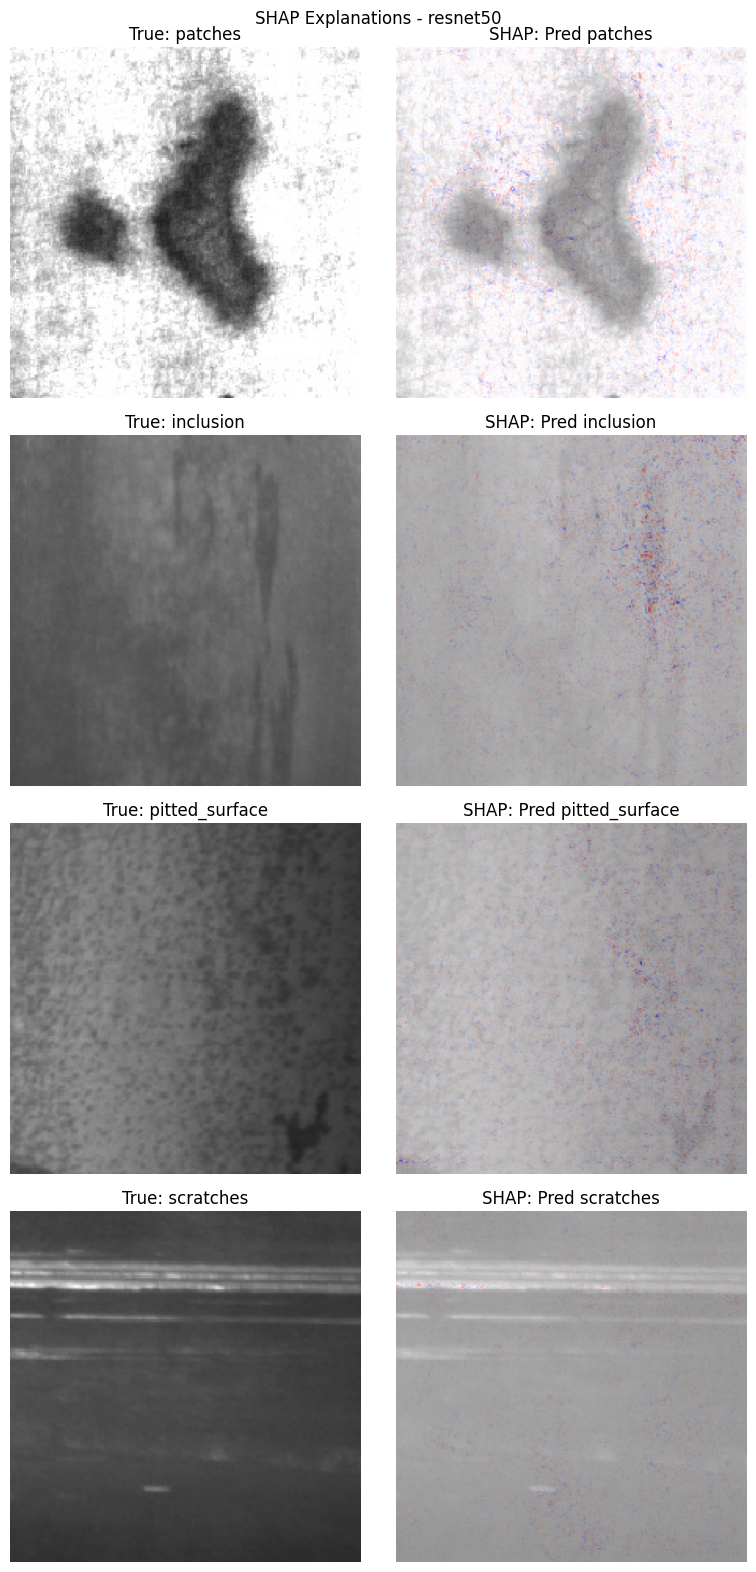

SHAP predictions: ['patches -> patches', 'inclusion -> inclusion', 'pitted_surface -> pitted_surface', 'scratches -> scratches']


In [ ]:
import shap

train_gens_map = {"custom_cnn": train_gen_cnn, "mobilenetv2": train_gen, "resnet50": train_gen_res}
best_train_gen = train_gens_map[best_model_name]
background_imgs, _ = next(best_train_gen)
background = background_imgs[:20]

best_test_gen = test_gens_map[best_model_name]
best_test_gen.reset()
shap_imgs, shap_labels = next(best_test_gen)      # preprocessed, for the MODEL
explain_imgs = shap_imgs[:4]

test_gen.reset()
display_shap_imgs, _ = next(test_gen)             # plain 0-1, for DISPLAY only
explain_display_imgs = display_shap_imgs[:4]

explainer = shap.GradientExplainer(best_model, background)
shap_values = explainer.shap_values(explain_imgs)

pred_probs = best_model.predict(explain_imgs, verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

fig, axes = plt.subplots(4, 2, figsize=(8,16))
for i in range(4):
    axes[i,0].imshow(explain_display_imgs[i]); axes[i,0].axis("off")
    true_idx = np.argmax(shap_labels[i])
    axes[i,0].set_title(f"True: {CLASS_NAMES[true_idx]}")

    if isinstance(shap_values, list):
        sv = shap_values[pred_classes[i]][i]
    else:
        sv = shap_values[i][..., pred_classes[i]]

    sv_gray = np.sum(sv, axis=-1)
    axes[i,1].imshow(explain_display_imgs[i])
    vmax = np.max(np.abs(sv_gray)) + 1e-8
    axes[i,1].imshow(sv_gray, cmap="bwr", alpha=0.5, vmin=-vmax, vmax=vmax)
    axes[i,1].axis("off")
    axes[i,1].set_title(f"SHAP: Pred {CLASS_NAMES[pred_classes[i]]}")

plt.suptitle(f"SHAP Explanations - {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "shap_examples.pdf"), dpi=300)
plt.savefig(os.path.join(FIG_DIR, "shap_examples.png"), dpi=300)
plt.show()

print("SHAP predictions:", [CLASS_NAMES[np.argmax(shap_labels[i])] + " -> " + CLASS_NAMES[pred_classes[i]] for i in range(4)])

# 17. Misclassified Examples

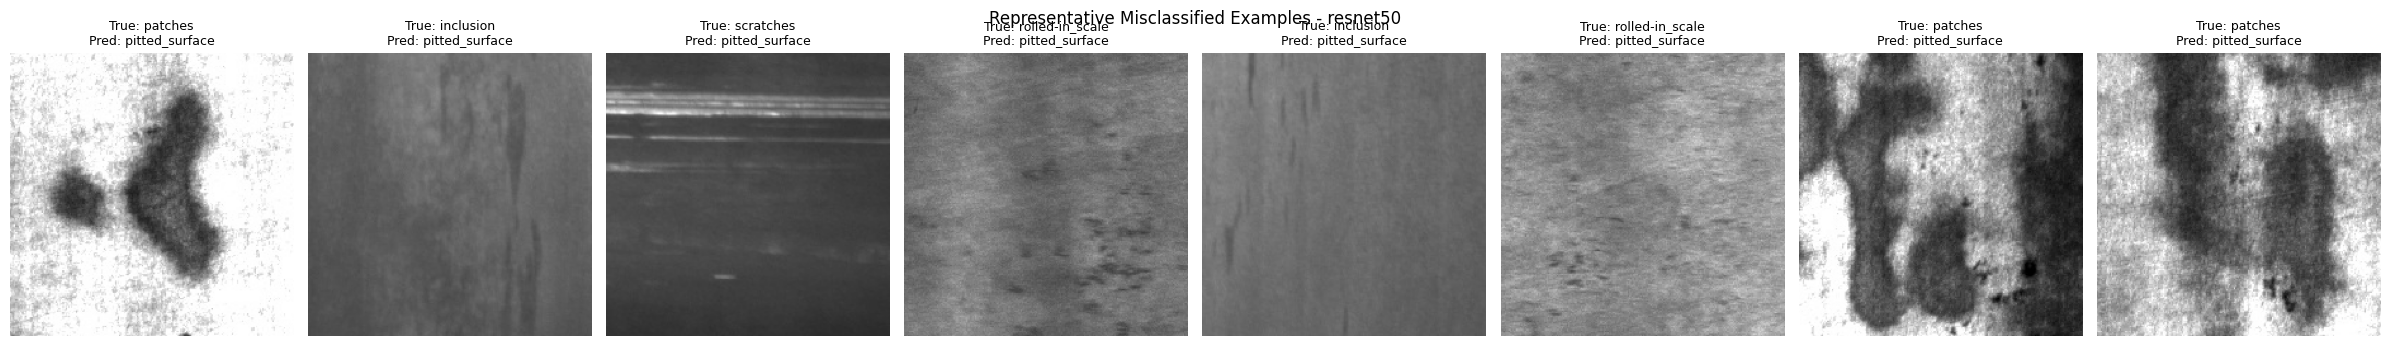

In [ ]:
best_test_gen = test_gens_map[best_model_name]
y_true_b, y_pred_b, _ = get_true_pred(best_model, best_test_gen)
misclassified_idx = np.where(y_true_b != y_pred_b)[0][:8]

best_test_gen.reset()
all_imgs = []
for _ in range(len(best_test_gen)):
    imgs, _ = next(best_test_gen)
    all_imgs.append(imgs)
all_imgs = np.concatenate(all_imgs, axis=0)[:len(y_true_b)]

if len(misclassified_idx) > 0:
    n = min(8, len(misclassified_idx))
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3.5))
    if n == 1: axes = [axes]
    for ax, idx in zip(axes, misclassified_idx[:n]):
        ax.imshow(all_imgs[idx])
        ax.set_title(f"True: {CLASS_NAMES[y_true_b[idx]]}\nPred: {CLASS_NAMES[y_pred_b[idx]]}", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"Representative Misclassified Examples - {best_model_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "misclassified_examples.pdf"), dpi=300)
    plt.savefig(os.path.join(FIG_DIR, "misclassified_examples.png"), dpi=300)
    plt.show()
else:
    print("No misclassified examples in this batch sample.")


# 18 Error Analysis: Misclassification Review & Class‑wise Performance

# 19  Demo Web Interface (Gradio)

 # 19 Graduation Extension: Larger Dataset, Real‑time Deployment, Segmentation‑based Localisation

# 20. Save All Results and Zip for Download

## 18. Final Evaluation and Reproducible Error Analysis

This section evaluates every model against its own deterministic test generator. Do not use an undefined generic `model` variable here.


In [ ]:
# Reproducible final evaluation: model <-> generator mapping is explicit.
final_results = {}
for name, model in model_objs.items():
    final_results[name] = evaluate_model(model, test_gens_map[name], name)

final_rows = []
for name, result in final_results.items():
    final_rows.append({
        "Model": name,
        "Accuracy": result["accuracy"],
        "Macro Precision": result["macro_precision"],
        "Macro Recall": result["macro_recall"],
        "Macro F1": result["macro_f1"],
        "Weighted F1": result["weighted_f1"],
        "AUC (macro)": result["auc_macro"],
    })

final_comparison = pd.DataFrame(final_rows).sort_values("Macro F1", ascending=False)
final_comparison.to_csv(os.path.join(TABLE_DIR, "model_comparison_final.csv"), index=False)
display(final_comparison)

best_model_name = final_comparison.iloc[0]["Model"]
best_model = model_objs[best_model_name]
best_test_gen = test_gens_map[best_model_name]

y_true, y_pred, y_prob = get_true_pred(best_model, best_test_gen)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
